<a href="https://colab.research.google.com/github/OlhaZahrebelna/python_for_ds_task/blob/main/Zahrebelna_Olha_%22HW_NLP_Classification_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [15]:
# =========================
# Основні бібліотеки
# =========================
import re

import numpy as np
import pandas as pd

# =========================
# Візуалізація
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# NLP та TensorFlow
# =========================
import nltk
import tensorflow as tf

from transformers import RobertaTokenizerFast

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# =========================
# Scikit-learn
# =========================
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer,
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# =========================
# Завантаження ресурсів NLTK
# =========================
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
df = pd.read_csv('train.csv')
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [4]:
df = df.dropna()
df.isna().sum()

,0
textID,0
text,0
selected_text,0
sentiment,0


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [5]:
df['sentiment'].value_counts()

,count
sentiment,
neutral,11117
positive,8582
negative,7781


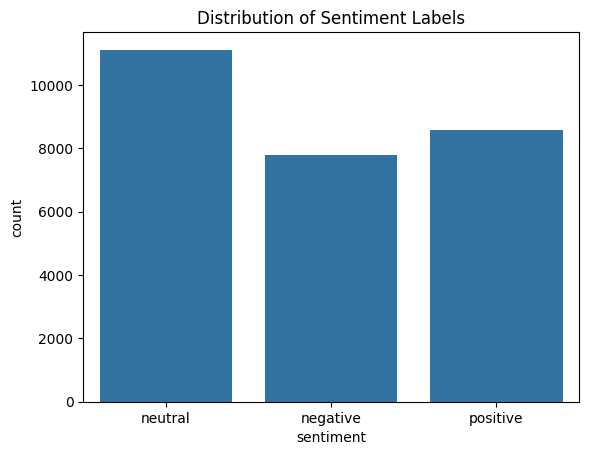

In [6]:
sns.countplot(x='sentiment', data=df)
plt.title('Distribution of Sentiment Labels')
plt.show()

Text(0, 0.5, 'Frequency')

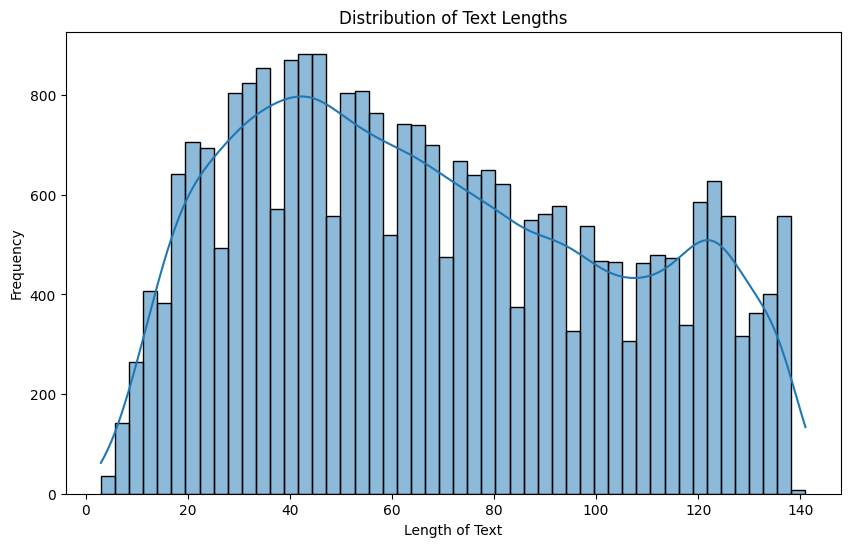

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['text'].str.len(), bins=50, kde=True)
plt.title('Distribution of Text Lengths')
plt.xlabel('Length of Text')
plt.ylabel('Frequency')

In [8]:
df_negative = df[df['sentiment'] == 'negative']
df_positive = df[df['sentiment'] == 'positive']
df_neutral = df[df['sentiment'] == 'neutral']

Text(0, 0.5, 'Frequency')

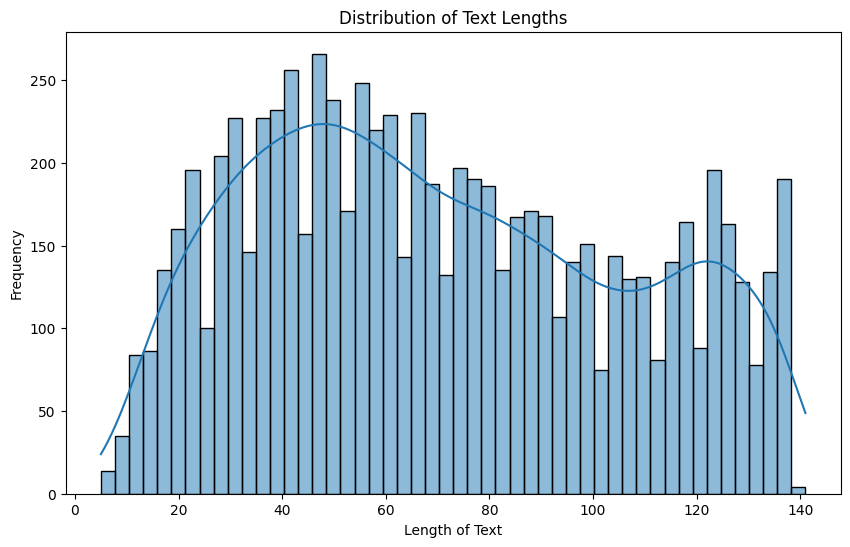

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df_negative['text'].str.len(), bins=50, kde=True)
plt.title('Distribution of Text Lengths Negative Sentiment')
plt.xlabel('Length of Text')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

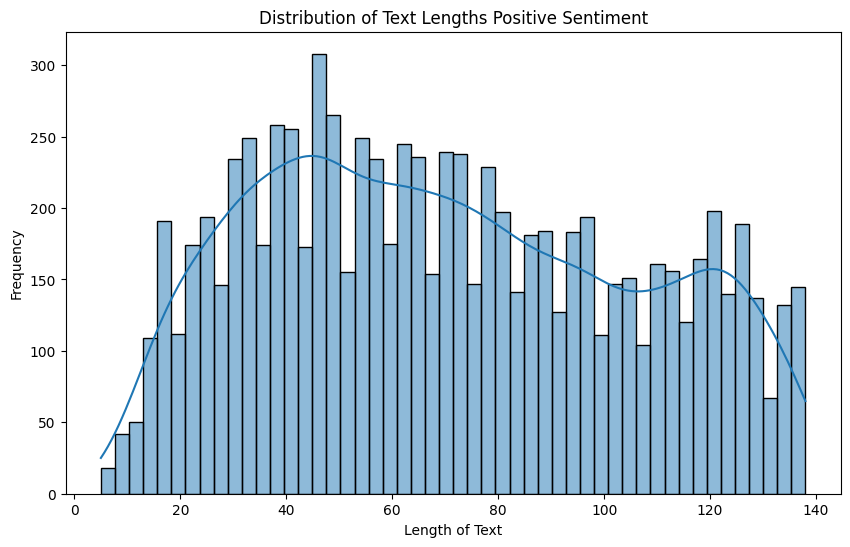

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df_positive['text'].str.len(), bins=50, kde=True)
plt.title('Distribution of Text Lengths Positive Sentiment')
plt.xlabel('Length of Text')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

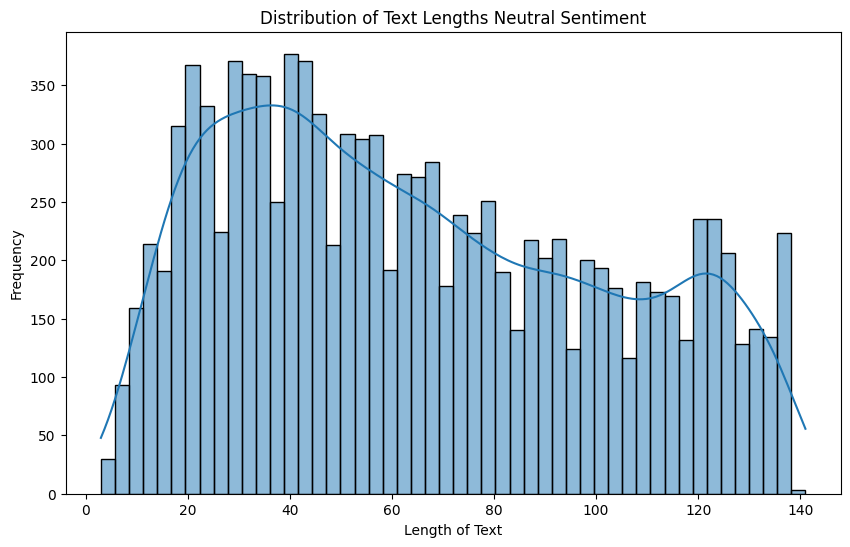

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df_neutral['text'].str.len(), bins=50, kde=True)
plt.title('Distribution of Text Lengths Neutral Sentiment')
plt.xlabel('Length of Text')
plt.ylabel('Frequency')

Аналіз розподілу класів показав, що датасет є частково незбалансованим. Найбільше у вибірці представлено нейтральних відгуків (neutral — 11117), тоді як позитивних (positive — 8582) та негативних (negative — 7781) менше. Проте різниця між класами не є критично великою.

Гістограма довжин текстів показує, що більшість постів мають середню довжину — приблизно від 30 до 90 символів. Дуже короткі тексти зустрічаються рідше, так само як і надто довгі. Розподіл є нерівномірним, із кількома піками, що може свідчити про наявність різних типів повідомлень у датасеті. Загалом тексти мають помірну довжину, що є зручним для NLP-моделей та подальшої обробки.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [12]:
stemmer = SnowballStemmer("english")
stop_words = set(stopwords.words("english"))

def nltk_preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    tokens = word_tokenize(text)

    tokens = [
        stemmer.stem(token)
        for token in tokens
        if token not in stop_words and len(token) > 1
    ]

    return " ".join(tokens)

In [16]:
df["clean_text"] = df["text"].apply(nltk_preprocess)

In [17]:
temp_vectorizer = CountVectorizer()

X_temp = temp_vectorizer.fit_transform(df["clean_text"])

print("Vocabulary size:", len(temp_vectorizer.vocabulary_))

Vocabulary size: 21518


In [18]:
word_counts = X_temp.sum(axis=0)

words = temp_vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({
    "word": words,
    "count": word_counts.A1
})

freq_df = freq_df.sort_values(by="count", ascending=False)

freq_df.tail(19018)

,word,count
2730,cab,8
4024,court,8
14772,punch,8
4125,crew,8
19404,twittervers,8
...,...,...
9,aaaaaaaahhhhhhhh,1
8,aaaaaaaafternoon,1
7,aaaaaaaaaamaz,1
6,aaaaaaaaaahhhhhhhh,1


In [19]:
vectorizer = CountVectorizer(max_features=2500)

X_bow = vectorizer.fit_transform(df["clean_text"])

X_bow.shape

(27480, 2500)

Після попередньої обробки корпус містить 21 518 унікальних слів. Частотний аналіз показав, що значна частина слів зустрічається рідко. Щоб зменшити розмірність ознакового простору та прибрати шум, було обрано max_features=2500, тобто залишено 2500 найчастіших слів.

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [20]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, df["sentiment"], test_size=0.2, random_state=42, stratify=df["sentiment"]
)

In [21]:
ln_model = LogisticRegression(max_iter=1000)
ln_model.fit(X_train_bow, y_train)
y_pred_ln = ln_model.predict(X_test_bow)
print(classification_report(y_test, y_pred_ln))

              precision    recall  f1-score   support

    negative       0.70      0.62      0.65      1556
     neutral       0.63      0.72      0.67      2223
    positive       0.76      0.70      0.73      1717

    accuracy                           0.68      5496
   macro avg       0.70      0.68      0.69      5496
weighted avg       0.69      0.68      0.69      5496



In [22]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_bow, y_train)
y_pred_dt = dt_model.predict(X_test_bow)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

    negative       0.60      0.62      0.61      1556
     neutral       0.61      0.60      0.60      2223
    positive       0.68      0.68      0.68      1717

    accuracy                           0.63      5496
   macro avg       0.63      0.63      0.63      5496
weighted avg       0.63      0.63      0.63      5496



In [23]:
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train_bow.toarray(), y_train)
y_pred_gb = gb_model.predict(X_test_bow.toarray())
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

    negative       0.77      0.44      0.56      1556
     neutral       0.57      0.83      0.68      2223
    positive       0.78      0.63      0.70      1717

    accuracy                           0.66      5496
   macro avg       0.71      0.63      0.65      5496
weighted avg       0.70      0.66      0.65      5496



Найкращі результати показала модель Logistic Regression. Вона досягла accuracy ≈ 0.68 та має найбільш збалансовані значення precision, recall і f1-score для всіх класів. Особливо добре модель класифікує позитивні та нейтральні відгуки.
Модель Decision Tree показала нижчу якість класифікації (accuracy ≈ 0.63), що свідчить про гіршу здатність узагальнювати текстові дані.
Gradient Boosting продемонстрував accuracy ≈ 0.66. Модель добре визначає нейтральні відгуки (recall = 0.83), однак гірше класифікує негативний клас.
Загалом якість класифікації можна оцінити як середню для NLP-підходу.

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [24]:
feature_importances = pd.Series(np.sum(np.abs(ln_model.coef_), axis=0), index=vectorizer.get_feature_names_out(), name='Importance')
feature_importances.sort_values(ascending=False).head(10)

,Importance
awesom,5.358440
sad,5.246905
shame,4.993549
suck,4.968632
cute,4.931959
sorri,4.892250
thank,4.869898
amaz,4.728881
love,4.719652
glad,4.652771


In [25]:
feature_importances.sort_values().head(10)

,Importance
tend,0.034689
suggest,0.035845
plane,0.036611
friendster,0.039808
ice,0.056460
tweeti,0.058205
need,0.059108
think,0.059919
real,0.061294
job,0.072313


Аналіз коефіцієнтів Logistic Regression показав, що найбільший вплив на класифікацію мають слова з яскраво вираженим емоційним забарвленням, наприклад love, awesome, amazing, sad, suck, shame. Це логічно, оскільки такі слова безпосередньо відображають позитивний або негативний сентимент тексту.
Найменший вплив мають нейтральні слова (job, real, need), які не несуть вираженої емоційної інформації.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [26]:
X_train, X_test, y_train_tfidf, y_test_tfidf = train_test_split(df['clean_text'], df['sentiment'], test_size=0.2, random_state=42, stratify=df['sentiment'])

tfidf = TfidfVectorizer(max_features=2500)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

ln_model_tfidf = LogisticRegression(max_iter=1000)

ln_model_tfidf.fit(X_train_tfidf, y_train_tfidf)
y_pred_tfidf = ln_model_tfidf.predict(X_test_tfidf)

print(classification_report(y_test_tfidf, y_pred_tfidf))

              precision    recall  f1-score   support

    negative       0.72      0.61      0.66      1556
     neutral       0.62      0.75      0.68      2223
    positive       0.77      0.69      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.71      0.68      0.69      5496
weighted avg       0.70      0.69      0.69      5496



In [27]:
feature_importances_tfidf = pd.Series(np.sum(np.abs(ln_model_tfidf.coef_), axis=0), index=tfidf.get_feature_names_out(), name='Importance')

feature_importances_tfidf.sort_values(ascending=False).head(10)

,Importance
love,12.599731
thank,10.909311
sad,10.131747
awesom,9.528047
miss,9.310160
sorri,8.651522
happi,8.611511
great,8.573700
nice,8.375327
hate,8.363732


In [28]:
feature_importances_tfidf.sort_values().head(10)

,Importance
order,0.020842
eat,0.021058
med,0.032337
card,0.041294
rang,0.056175
cd,0.058385
space,0.059467
lovato,0.060578
gd,0.067504
wash,0.069993


Після навчання Logistic Regression на TF-IDF векторах модель показала краще за результат Bag of Words (~0.68).
Найбільш впливовими токенами для TF-IDF стали слова з яскраво вираженим емоційним забарвленням: love, thank, sad, awesome, great, hate. Це логічно, оскільки такі слова безпосередньо характеризують сентимент повідомлення.
У порівнянні з Bag of Words, TF-IDF краще виділяє інформативні слова та зменшує вплив дуже частих загальних токенів.
Для фінальної імплементації я б обрала TF-IDF, оскільки він показав дещо кращу якість класифікації та краще відображає важливість окремих слів у документах.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [29]:
errors = pd.DataFrame({
    "text": X_test,
    "true": y_test_tfidf,
    "pred": y_pred_tfidf
})

errors = errors[errors["true"] != errors["pred"]]
errors.head(20)

,text,true,pred
23414,read take note undertand none help,negative,neutral
24609,wow morn hrs ding dong breakfastservic surpris...,positive,neutral
20627,im sooo lovei think,positive,neutral
4832,yum home deliveri,positive,neutral
19360,wonder piec cake lunch els could want,positive,neutral
24967,dont worri youll get stamina back soon kind di...,positive,neutral
10652,shack idol today cant wait gon na funnn poor c...,neutral,negative
17484,hug wish could help,negative,positive
10247,youtub isnt workingand want watch britain got ...,negative,neutral
5693,dont know guy radio disney much energi wouldnt...,neutral,negative


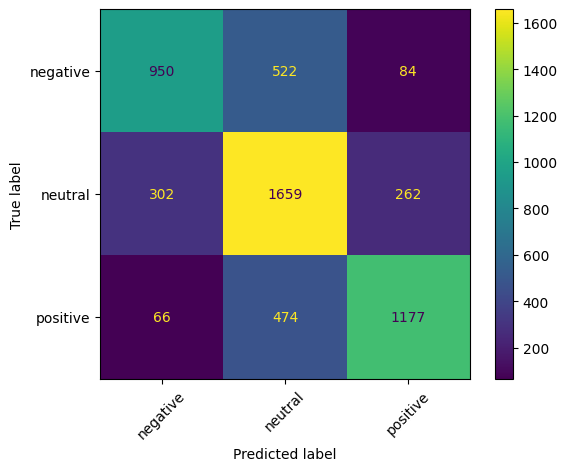

In [30]:
ConfusionMatrixDisplay.from_predictions(
    y_test_tfidf,
    y_pred_tfidf,
    xticks_rotation=45
)
plt.show()

Аналіз confusion matrix показав, що модель найкраще класифікує клас neutral, оскільки він має найбільшу кількість правильних передбачень (1659). Також модель достатньо добре розпізнає positive та negative класи. Основна кількість помилок пов’язана з тим, що позитивні та негативні повідомлення часто класифікуються як neutral. Наприклад, 522 негативних повідомлення були передбачені як neutral, а також 474 позитивних повідомлення були помилково віднесені до neutral. Водночас модель рідко плутає positive та negative між собою, що свідчить про те, що TF-IDF + Logistic Regression добре вловлює загальний polarity sentiment, але має труднощі зі слабко вираженими емоціями та короткими текстами.

Це може бути пов’язано з тим, що після препроцесингу частина емоційного контексту була втрачена: видалено пунктуацію, емодзі та деякі мовні конструкції. Крім того, TF-IDF не враховує порядок слів і контекст речення.

###3 шляхи поліпшення:

Додати ngram_range=(1,2) або (1,3), щоб модель бачила фрази типу not good, very happy, so sad

Не видаляти повністю пунктуацію, емодзі та заперечення, бо вони несуть сентимент.

Спробувати інші моделі

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model